# Prueba Técnica Data & AI

## 0. Setup y Exploración

### 0.1 Imports

In [177]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans




In [44]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### 0.2 Data Ingestion

In [45]:
df = pd.read_csv('../data/dataset_prueba_tecnica.csv')

### 0.3 EDA

#### General

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id_cliente                  250000 non-null  object 
 1   tipo_cliente                250000 non-null  object 
 2   region                      250000 non-null  object 
 3   edad                        250000 non-null  int64  
 4   antiguedad_meses            250000 non-null  int64  
 5   ingreso_mensual_mxn         250000 non-null  float64
 6   score_buro                  250000 non-null  int64  
 7   num_productos_activos       250000 non-null  int64  
 8   uso_tdc_pct                 250000 non-null  float64
 9   num_consultas_buro_6m       250000 non-null  int64  
 10  tiene_mora_actual           250000 non-null  int64  
 11  canal_preferente            250000 non-null  object 
 12  num_contactos_previos_12m   250000 non-null  int64  
 13  dias_desde_ult

In [47]:
df.head()

,id_cliente,tipo_cliente,region,edad,antiguedad_meses,ingreso_mensual_mxn,score_buro,num_productos_activos,uso_tdc_pct,num_consultas_buro_6m,tiene_mora_actual,canal_preferente,num_contactos_previos_12m,dias_desde_ultimo_contacto,oferta_tasa_pct,monto_ofertado_mxn,grupo_experimental,contactado,costo_contacto_mxn,contrato,monto_contratado_mxn,mora_90d_post_6m
0,C100000,Recompra,Occidente,46,28,19582.0,684,1,42.3,1,0,Web,4,236,29.92,39800.0,Tratamiento,1,18,0,0.0,NaN
1,C100001,Nuevo,Sureste,21,0,12262.0,484,0,75.3,5,0,Call Center,3,82,26.90,32800.0,Tratamiento,1,75,0,0.0,NaN
2,C100002,Recompra,Sureste,21,66,8936.0,516,1,45.0,1,0,App,5,221,21.33,18600.0,Tratamiento,1,12,0,0.0,NaN
3,C100003,Recompra,Sureste,51,33,9347.0,491,3,50.1,4,0,App,1,204,26.33,20000.0,Control,0,0,0,0.0,NaN
4,C100004,Nuevo,Norte,22,0,14134.0,404,0,77.0,2,0,App,1,89,21.39,49400.0,Tratamiento,1,12,0,0.0,NaN


In [48]:
df.duplicated().sum() # sin dups completos

np.int64(0)

In [49]:
df['id_cliente'].nunique() # 75 clientes con id dup

249925

In [50]:
df[df['id_cliente'].duplicated()]['id_cliente']

5598      C105598
19104     C119104
38015     C138015
50393     C147630
51107     C148879
58230     C158230
78583     C178583
88861     C148272
90437     C190437
93309     C185189
103080    C203080
108039    C203631
109699    C209699
114723    C193573
114774    C132282
114886    C214886
117271    C163138
117436    C217436
119689    C175689
124862    C224862
128636    C228636
128863    C205060
135235    C235235
135322    C235322
138225    C208344
139075    C235700
142253    C174154
143298    C243298
153788    C225583
155015    C119171
156181    C112386
170305    C252182
172531    C156188
173347    C206111
174130    C144109
174737    C274737
175459    C275459
178238    C278238
181508    C281508
182113    C282113
182626    C120791
183405    C283405
185250    C170347
186249    C286249
188533    C288533
194852    C223179
196043    C157035
196653    C273606
197618    C295610
198135    C298135
198825    C152487
201045    C255782
205833    C240306
209032    C171649
209553    C309553
212007    

In [51]:
df[df.duplicated(subset=['id_cliente'], keep=False)].sort_values(by='id_cliente')

,id_cliente,tipo_cliente,region,edad,antiguedad_meses,ingreso_mensual_mxn,score_buro,num_productos_activos,uso_tdc_pct,num_consultas_buro_6m,tiene_mora_actual,canal_preferente,num_contactos_previos_12m,dias_desde_ultimo_contacto,oferta_tasa_pct,monto_ofertado_mxn,grupo_experimental,contactado,costo_contacto_mxn,contrato,monto_contratado_mxn,mora_90d_post_6m
4968,C105598,Nuevo,Sureste,39,0,21529.0,696,0,12.0,1,0,Web,3,86,24.79,54900.0,Tratamiento,1,18,0,0.0,NaN
5598,C105598,Nuevo,Occidente,40,0,24702.0,584,0,94.9,2,0,Sucursal,2,225,25.14,115900.0,Tratamiento,1,150,0,0.0,NaN
156181,C112386,Nuevo,Occidente,45,0,12427.0,533,0,57.5,1,1,App,2,55,28.99,47700.0,Tratamiento,1,12,0,0.0,NaN
12386,C112386,Nuevo,Norte,48,0,20554.0,544,0,26.4,3,1,Sucursal,4,205,26.51,49900.0,Tratamiento,1,150,0,0.0,NaN
6149,C119104,Recompra,CDMX,35,78,47317.0,782,1,50.2,3,0,Web,2,249,23.54,216000.0,Tratamiento,1,18,1,193400.0,0.0
19104,C119104,Nuevo,Occidente,43,0,24894.0,599,0,19.0,0,0,Web,3,321,29.77,94600.0,Tratamiento,1,18,0,0.0,NaN
155015,C119171,Recompra,Norte,56,69,32423.0,707,4,94.6,1,0,Sucursal,1,298,30.54,83800.0,Tratamiento,1,150,0,0.0,NaN
19171,C119171,Recompra,CDMX,31,28,15450.0,661,0,42.7,3,0,Web,1,12,26.42,31500.0,Tratamiento,1,18,0,0.0,NaN
182626,C120791,Nuevo,CDMX,46,0,27802.0,645,0,38.5,3,0,Web,2,339,29.37,131400.0,Tratamiento,1,18,0,0.0,NaN
20791,C120791,Nuevo,Bajio,43,0,17867.0,578,0,24.1,6,0,Sucursal,6,202,33.61,68400.0,Tratamiento,1,150,0,0.0,NaN


In [52]:
df_clean = df[~df.duplicated(subset=['id_cliente'], keep=False)].copy() # eliminarmos 150 registros (aquellos que tienen id_cliente duplicado, ya que no sabemos cuál es el correcto). Aceptamos perder información de 150 registros de 250,000.

#### tipo_cliente

In [53]:
print(df_clean['tipo_cliente'].value_counts())
print(df['tipo_cliente'].value_counts(normalize=True) * 100)

tipo_cliente
Nuevo       149690
Recompra    100160
Name: count, dtype: int64
tipo_cliente
Nuevo       59.9124
Recompra    40.0876
Name: proportion, dtype: float64


In [54]:
# tienen sentido los valores de antiguedad_meses y num_productos_activos para cada tipo_cliente?
df.groupby('tipo_cliente')[['antiguedad_meses', 'num_productos_activos']].agg(['min', 'max', 'mean'])

antiguedad_meses                 num_productos_activos      \
                          min  max       mean                   min max   
tipo_cliente                                                              
Nuevo                       0    0   0.000000                     0   0   
Recompra                    6  240  66.154272                     0   6   

                        
                  mean  
tipo_cliente            
Nuevo         0.000000  
Recompra      1.594488

#### region

In [55]:
print(df_clean['region'].value_counts())
print(df_clean['region'].value_counts(normalize=True) * 100)

region
CDMX         69509
Norte        55496
Occidente    45161
Bajio        42296
Sureste      37388
Name: count, dtype: int64
region
CDMX         27.820292
Norte        22.211727
Occidente    18.075245
Bajio        16.928557
Sureste      14.964179
Name: proportion, dtype: float64


#### edad

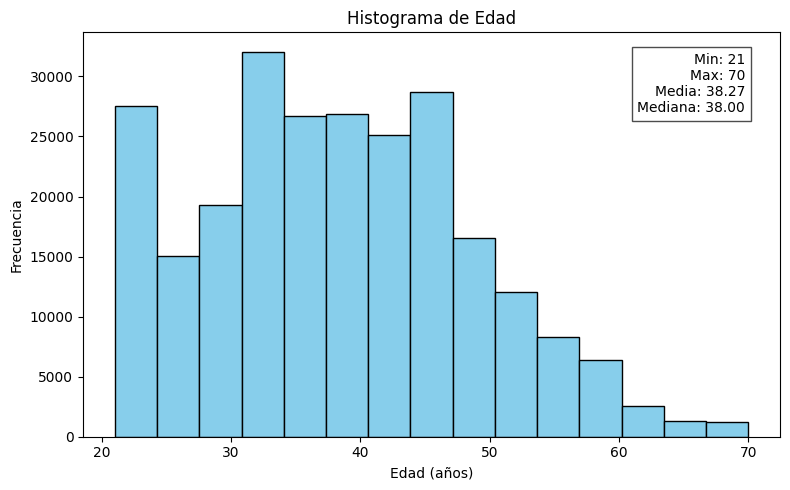

In [182]:

edad = df_clean["edad"]

# Calcular estadísticas
min_edad = edad.min()
max_edad = edad.max()
media = edad.mean()
mediana = edad.median()

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.hist(edad, bins=15, color='skyblue', edgecolor='black')
plt.title('Histograma de Edad')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')

stats_text = (
    f"Min: {min_edad:.0f}\n"
    f"Max: {max_edad:.0f}\n"
    f"Media: {media:.2f}\n"
    f"Mediana: {mediana:.2f}"
)
plt.text(x=0.95, y=0.95, s=stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()


In [57]:
df_clean['edad'].value_counts()

edad
21     16901
39      9048
38      9035
36      9011
37      8937
35      8777
40      8762
41      8619
34      8561
42      8485
33      8184
43      8050
32      7960
44      7795
45      7478
31      7369
46      6943
30      6782
29      6497
47      6496
28      5991
48      5960
49      5570
27      5553
50      5014
26      4938
25      4550
51      4480
52      4025
24      3995
23      3594
53      3560
54      3190
22      3056
55      2834
56      2310
57      2020
58      1789
59      1399
60      1220
61      1030
62       840
63       679
64       563
70       552
65       438
66       323
67       284
68       222
69       156
3         13
130        8
145        4
Name: count, dtype: int64

In [58]:
df_clean = df_clean[(df_clean['edad'] >= 18) & (df_clean['edad'] <= 100)] # de 249850 a 249825 registros

#### ingreso_mensual_mxn

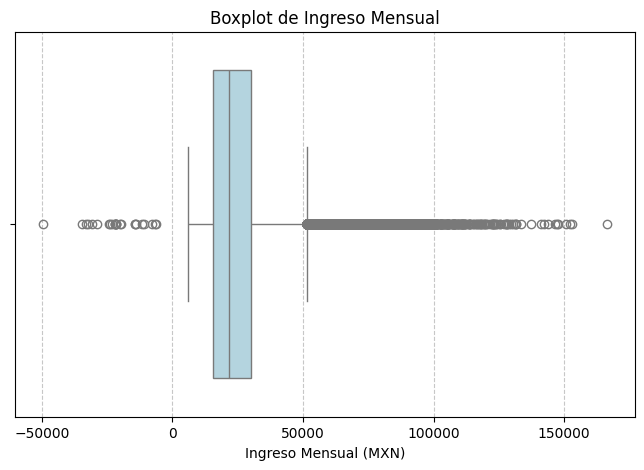

In [59]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["ingreso_mensual_mxn"], color='lightblue')
plt.title("Boxplot de Ingreso Mensual")
plt.xlabel("Ingreso Mensual (MXN)")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


In [60]:
(df_clean["ingreso_mensual_mxn"] < 0).sum()

np.int64(25)

In [61]:
df_clean = df_clean[df_clean["ingreso_mensual_mxn"] >= 0]

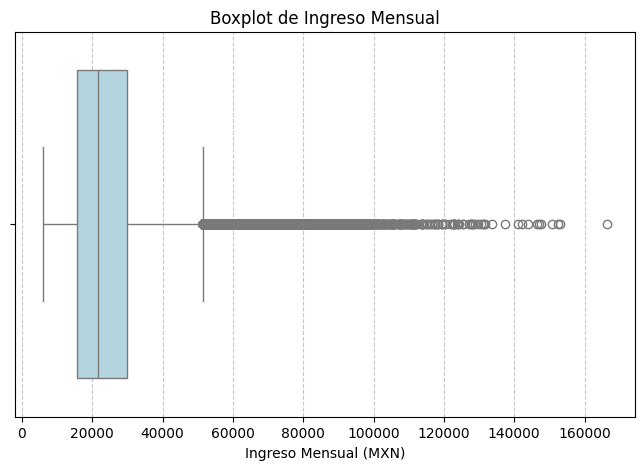

In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["ingreso_mensual_mxn"], color='lightblue')
plt.title("Boxplot de Ingreso Mensual")
plt.xlabel("Ingreso Mensual (MXN)")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


In [64]:
(df_clean["ingreso_mensual_mxn"] == 0).sum()

np.int64(0)

In [68]:
df_clean['ingreso_mensual_mxn'].describe()

count    249800.000000
mean      24266.357094
std       12301.987018
min        6000.000000
25%       15621.000000
50%       21629.000000
75%       29923.000000
max      166291.000000
Name: ingreso_mensual_mxn, dtype: float64

#### score_buro

In [70]:
df_clean['score_buro'].describe()

count    249800.000000
mean        620.080633
std          81.763063
min         120.000000
25%         565.000000
50%         619.000000
75%         675.000000
max        1500.000000
Name: score_buro, dtype: float64

In [71]:
((df_clean["score_buro"] < 330) | (df_clean["score_buro"] > 850)).sum()

np.int64(51)

In [72]:
df_clean = df_clean[(df_clean["score_buro"] >= 330) & (df_clean["score_buro"] <= 850)]

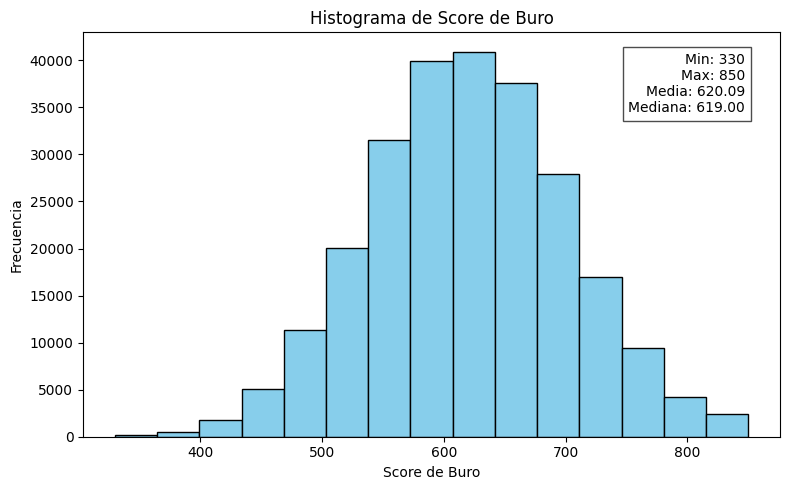

In [73]:

score_buro = df_clean["score_buro"]

# Calcular estadísticas
min_score_buro = score_buro.min()
max_score_buro = score_buro.max()
media_score_buro = score_buro.mean()
mediana = score_buro.median()

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.hist(score_buro, bins=15, color='skyblue', edgecolor='black')
plt.title('Histograma de Score de Buro')
plt.xlabel('Score de Buro')
plt.ylabel('Frecuencia')

stats_text = (
    f"Min: {min_score_buro:.0f}\n"
    f"Max: {max_score_buro:.0f}\n"
    f"Media: {media_score_buro:.2f}\n"
    f"Mediana: {mediana:.2f}"
)
plt.text(x=0.95, y=0.95, s=stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()


#### num_productos_activos

In [83]:
df_clean['num_productos_activos'].value_counts()

num_productos_activos
0    169999
1     32490
2     25726
3     13492
4      5620
5      1788
6       634
Name: count, dtype: int64

In [74]:
df_clean['num_productos_activos'].describe()

count    249749.000000
mean          0.639210
std           1.118099
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           6.000000
Name: num_productos_activos, dtype: float64

#### uso_tdc_pct

In [75]:
df_clean['uso_tdc_pct'].describe()

count    249749.000000
mean         55.310167
std          27.356660
min           0.000000
25%          36.200000
50%          55.100000
75%          73.900000
max         140.000000
Name: uso_tdc_pct, dtype: float64

In [ ]:
(df_clean["uso_tdc_pct"] > 100).sum() # 13,428 usuarios tienen un uso de tarjeta de crédito mayor al 100%

np.int64(13428)

#### num_consultas_buro_6m

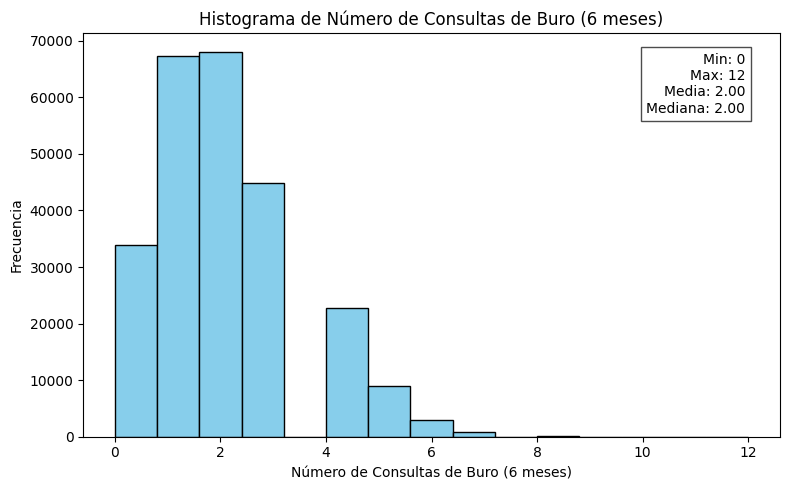

In [77]:

num_consultas_buro_6m = df_clean["num_consultas_buro_6m"]

# Calcular estadísticas
min_num_consultas_buro_6m = num_consultas_buro_6m.min()
max_num_consultas_buro_6m = num_consultas_buro_6m.max()
media_num_consultas_buro_6m = num_consultas_buro_6m.mean()
mediana_num_consultas_buro_6m = num_consultas_buro_6m.median()

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.hist(num_consultas_buro_6m, bins=15, color='skyblue', edgecolor='black')
plt.title('Histograma de Número de Consultas de Buro (6 meses)')
plt.xlabel('Número de Consultas de Buro (6 meses)')
plt.ylabel('Frecuencia')

stats_text = (
    f"Min: {min_num_consultas_buro_6m:.0f}\n"
    f"Max: {max_num_consultas_buro_6m:.0f}\n"
    f"Media: {media_num_consultas_buro_6m:.2f}\n"
    f"Mediana: {mediana_num_consultas_buro_6m:.2f}"
)
plt.text(x=0.95, y=0.95, s=stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()


In [ ]:
df_clean['num_consultas_buro_6m'].value_counts()

num_consultas_buro_6m
2     68002
1     67353
3     44851
0     33841
4     22674
5      8914
6      3044
7       819
8       208
9        32
10        8
11        2
12        1
Name: count, dtype: int64

#### tiene_mora_actual

In [80]:
df_clean['tiene_mora_actual'].value_counts()

tiene_mora_actual
0    214634
1     35115
Name: count, dtype: int64

#### canal_preferente

In [82]:
df_clean['canal_preferente'].value_counts()

canal_preferente
App            74686
Call Center    62732
Sucursal       62435
Web            49896
Name: count, dtype: int64

#### num_contactos_previos_12m

In [ ]:
df_clean['num_contactos_previos_12m'].value_counts()

num_contactos_previos_12m
2     66107
1     57711
3     50606
4     29144
0     24984
5     13625
6      5180
7      1734
8       503
9       119
10       28
11        7
13        1
Name: count, dtype: int64

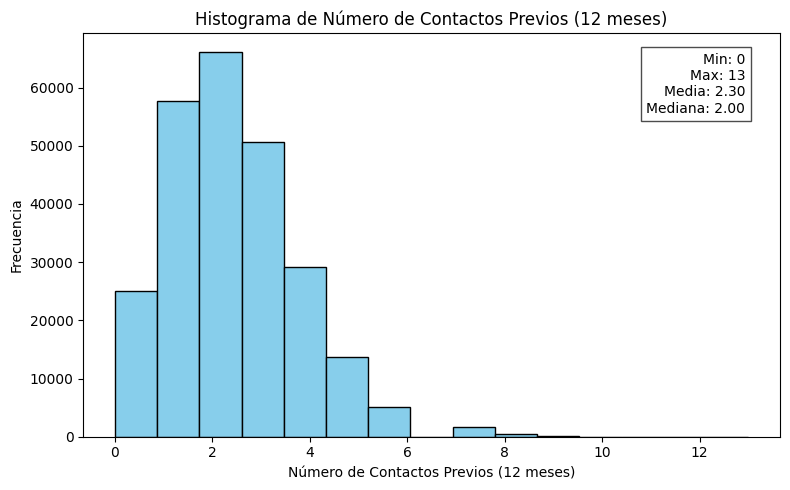

In [86]:

num_contactos_previos_12m = df_clean["num_contactos_previos_12m"]

# Calcular estadísticas
min_num_contactos_previos_12m = num_contactos_previos_12m.min()
max_num_contactos_previos_12m = num_contactos_previos_12m.max()
media_num_contactos_previos_12m = num_contactos_previos_12m.mean()
mediana_num_contactos_previos_12m = num_contactos_previos_12m.median()

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.hist(num_contactos_previos_12m, bins=15, color='skyblue', edgecolor='black')
plt.title('Histograma de Número de Contactos Previos (12 meses)')
plt.xlabel('Número de Contactos Previos (12 meses)')
plt.ylabel('Frecuencia')

stats_text = (
    f"Min: {min_num_contactos_previos_12m:.0f}\n"
    f"Max: {max_num_contactos_previos_12m:.0f}\n"
    f"Media: {media_num_contactos_previos_12m:.2f}\n"
    f"Mediana: {mediana_num_contactos_previos_12m:.2f}"
)
plt.text(x=0.95, y=0.95, s=stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()


#### dias_desde_ultimo_contacto

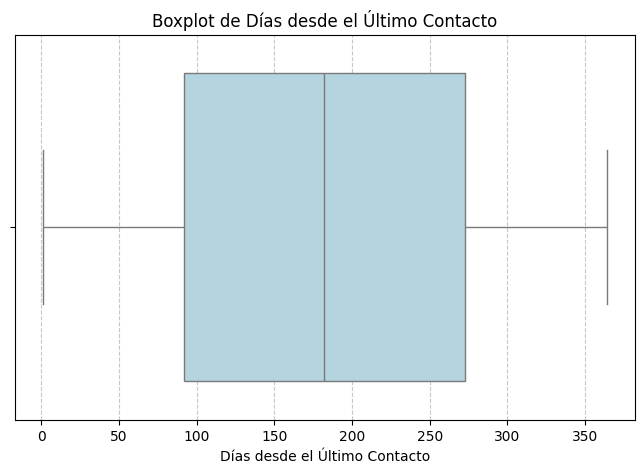

In [89]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["dias_desde_ultimo_contacto"], color='lightblue')
plt.title("Boxplot de Días desde el Último Contacto")
plt.xlabel("Días desde el Último Contacto")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


In [90]:
df_clean['dias_desde_ultimo_contacto'].describe()

count    249749.000000
mean        182.440722
std         105.042635
min           1.000000
25%          92.000000
50%         182.000000
75%         273.000000
max         364.000000
Name: dias_desde_ultimo_contacto, dtype: float64

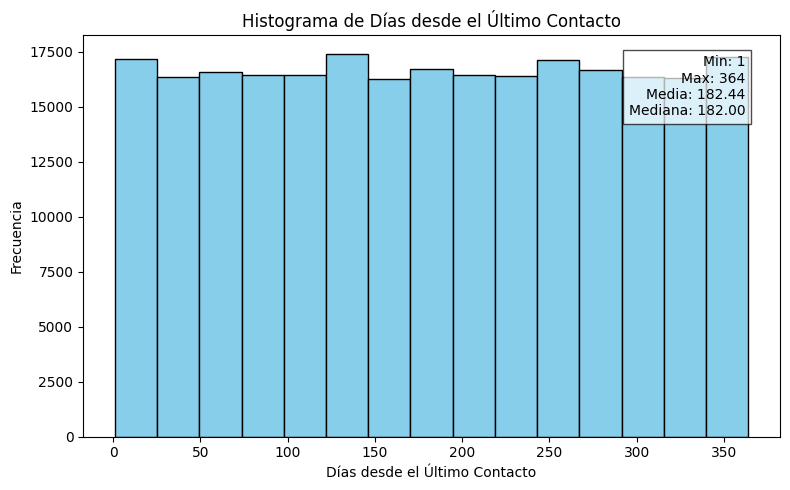

In [91]:

dias_desde_ultimo_contacto = df_clean["dias_desde_ultimo_contacto"]

# Calcular estadísticas
min_dias_desde_ultimo_contacto = dias_desde_ultimo_contacto.min()
max_dias_desde_ultimo_contacto = dias_desde_ultimo_contacto.max()
media_dias_desde_ultimo_contacto = dias_desde_ultimo_contacto.mean()
mediana_dias_desde_ultimo_contacto = dias_desde_ultimo_contacto.median()

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.hist(dias_desde_ultimo_contacto, bins=15, color='skyblue', edgecolor='black')
plt.title('Histograma de Días desde el Último Contacto')
plt.xlabel('Días desde el Último Contacto')
plt.ylabel('Frecuencia')

stats_text = (
    f"Min: {min_dias_desde_ultimo_contacto:.0f}\n"
    f"Max: {max_dias_desde_ultimo_contacto:.0f}\n"
    f"Media: {media_dias_desde_ultimo_contacto:.2f}\n"
    f"Mediana: {mediana_dias_desde_ultimo_contacto:.2f}"
)
plt.text(x=0.95, y=0.95, s=stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()


#### oferta_tasa_pct 

In [92]:
df_clean['oferta_tasa_pct'].describe()

count    249749.000000
mean         26.022757
std           5.024124
min          14.000000
25%          22.580000
50%          26.010000
75%          29.440000
max          42.000000
Name: oferta_tasa_pct, dtype: float64

#### monto_ofertado_mxn

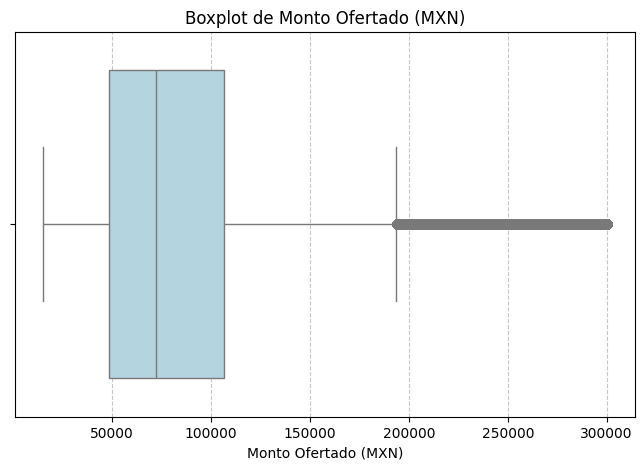

In [93]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["monto_ofertado_mxn"], color='lightblue')
plt.title("Boxplot de Monto Ofertado (MXN)")
plt.xlabel("Monto Ofertado (MXN)")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


In [95]:
df_clean['monto_ofertado_mxn'].describe()

count    249749.000000
mean      84165.862926
std       50094.251343
min       15000.000000
25%       48500.000000
50%       71900.000000
75%      106600.000000
max      300000.000000
Name: monto_ofertado_mxn, dtype: float64

#### grupo_experimental, contactado y costo_contacto_mxn

In [99]:
display(df_clean['grupo_experimental'].value_counts(normalize=True))
df_clean['grupo_experimental'].value_counts()

grupo_experimental
Tratamiento    0.850021
Control        0.149979
Name: proportion, dtype: float64

grupo_experimental
Tratamiento    212292
Control         37457
Name: count, dtype: int64

In [105]:
len(df_clean[(df_clean['grupo_experimental'] == 'Control') & (df_clean['contactado'] == 1)]) # es correcto que si son del grupo de control, no deberían haber sido contactados

0

In [104]:
len(df_clean[(df_clean['contactado'] == 0) & (df_clean['costo_contacto_mxn'] > 0)]) # es correcto que si no fueron contactados, no deberían tener costo de contacto

0

In [108]:
df_clean['contactado'].value_counts(normalize=True)


contactado
1    0.850021
0    0.149979
Name: proportion, dtype: float64

In [109]:
df_clean['costo_contacto_mxn'].describe()

count    249749.000000
mean         54.084757
std          56.249044
min           0.000000
25%          12.000000
50%          18.000000
75%          75.000000
max         150.000000
Name: costo_contacto_mxn, dtype: float64

#### variables objetivo: contrato, monto_contratado_mxn, mora_90d_post_6m

In [ ]:
len(df_clean[(df_clean['contrato'] == 1) & (df_clean['monto_contratado_mxn'] <= 0)]) # es correcto que si se contrató un producto, el monto contratado debería ser mayor a 0

0

In [ ]:
len(df_clean[(df_clean['contrato'] == 0) & (df_clean['monto_contratado_mxn'] > 0)]) # es correcto que si no se contrató un producto, el monto contratado debería ser 0

0

In [ ]:
len(df_clean[(df_clean['contrato'] == 0) & (df_clean['mora_90d_post_6m'].notna())]) # es correcto que si no se contrató un producto, no debería haber información de mora a 90 días post 6 meses

0

In [120]:
tasa_conversion = df_clean['contrato'].mean() * 100
tasa_mora_post = df_clean['mora_90d_post_6m'].mean() * 100  # pandas omite los NaN automáticamente

print(f"\n--- Métricas Base (KPIs) ---")
print(f"Tasa de conversión global: {tasa_conversion:.2f}%")
print(f"Tasa de mora posterior (sobre contratados): {tasa_mora_post:.2f}%")


--- Métricas Base (KPIs) ---
Tasa de conversión global: 17.14%
Tasa de mora posterior (sobre contratados): 13.06%


## 1. Pregunta 1: Estrategia de Priorización

### 1.1 Preparación de Datos para Modelado

In [121]:
#excluimos las columnas que ocurren durante o después del contacto
columnas_excluir = [
    'id_cliente', 'grupo_experimental', 'contactado', 'costo_contacto_mxn', 
    'contrato', 'monto_contratado_mxn', 'mora_90d_post_6m'
]

In [122]:
X_raw = df_clean.drop(columns=columnas_excluir)

In [123]:
# dummy encoding de variables categóricas
X = pd.get_dummies(X_raw, columns=['tipo_cliente', 'region', 'canal_preferente'], drop_first=True)

In [128]:
X.columns = X.columns.str.replace(' ', '_')

Columnas normalizadas: ['edad', 'antiguedad_meses', 'ingreso_mensual_mxn', 'score_buro', 'num_productos_activos', 'uso_tdc_pct', 'num_consultas_buro_6m', 'tiene_mora_actual', 'num_contactos_previos_12m', 'dias_desde_ultimo_contacto', 'oferta_tasa_pct', 'monto_ofertado_mxn', 'tipo_cliente_Recompra', 'region_CDMX', 'region_Norte', 'region_Occidente', 'region_Sureste', 'canal_preferente_Call_Center', 'canal_preferente_Sucursal', 'canal_preferente_Web']


In [124]:
#Target (Y) y el Tratamiento (T)

Y = df_clean['contrato']
T = df_clean['contactado'] # 1 si fue tratado, 0 si fue control

In [126]:
# Validar dimensiones
print(f"Dimensiones de los predictores (X): {X.shape}")
print(f"Dimensiones del Target (Y): {Y.shape}")
print(f"Dimensiones del Tratamiento (T): {T.shape}")

Dimensiones de los predictores (X): (249749, 20)
Dimensiones del Target (Y): (249749,)
Dimensiones del Tratamiento (T): (249749,)


In [138]:
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, Y, T, test_size=0.3, random_state=42, stratify=Y
)

In [140]:
#Separar Train por grupos experimentales
X_train_tratamiento = X_train[t_train == 1]
y_train_tratamiento = y_train[t_train == 1]

X_train_control = X_train[t_train == 0]
y_train_control = y_train[t_train == 0]

### 1.2 Entrenamiento del Modelo (T-Learner/Random Forest)

In [141]:
modelo_a = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
modelo_b = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)

modelo_a.fit(X_train_tratamiento, y_train_tratamiento)
modelo_b.fit(X_train_control, y_train_control)

,n_estimators,100
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 1.3 Generación del Score

In [142]:
prob_t_test = modelo_a.predict_proba(X_test)[:, 1]
prob_c_test = modelo_b.predict_proba(X_test)[:, 1]
uplift_test = prob_t_test - prob_c_test

In [143]:
#resultados de Test para validación
resultados_test = pd.DataFrame({
    'uplift_predicho': uplift_test,
    'tratamiento': t_test,
    'contrato': y_test
})

In [ ]:
# Crear deciles (1 = mayor persuasión predicha, 10 = menor persuasión predicha)
resultados_test['decil'] = pd.qcut(resultados_test['uplift_predicho'], 10, labels=False, duplicates='drop')
# Invertir orden para que el decil 1 sea el top
resultados_test['decil'] = resultados_test['decil'].max() - resultados_test['decil'] + 1 

In [145]:
# Calcular la tasa real de conversión empírica por grupo y decil
validacion = resultados_test.groupby(['decil', 'tratamiento'])['contrato'].mean().unstack()
validacion.columns = ['conv_control', 'conv_tratamiento']

In [ ]:
# ¿Se cumple nuestro pronóstico en la realidad?
validacion['uplift_real'] = validacion['conv_tratamiento'] - validacion['conv_control']

print("--- Evaluación Causal por Deciles  ---")
display(validacion.style.format("{:.2%}").background_gradient(subset=['uplift_real'], cmap='Greens'))

--- Evaluación Causal por Deciles (Out-of-Sample) ---


,conv_control,conv_tratamiento,uplift_real
decil,,,
1,32.95%,43.67%,10.72%
2,20.27%,31.06%,10.79%
3,16.31%,26.12%,9.80%
4,14.08%,20.78%,6.70%
5,11.19%,15.80%,4.61%
6,8.92%,12.41%,3.49%
7,7.45%,10.56%,3.11%
8,4.05%,8.12%,4.06%
9,4.57%,6.59%,2.02%


In [ ]:
#1. aplicar los modelos ya entrenados a TODA la base limpia
prob_tratamiento_full = modelo_a.predict_proba(X)[:, 1]
prob_control_full = modelo_b.predict_proba(X)[:, 1]
df_clean['uplift_conversion'] = prob_tratamiento_full - prob_control_full

/var/folders/35/9jk9l9v12pdd0pfk5m__mvwm0000gn/T/ipykernel_85115/2399379905.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['uplift_conversion'] = prob_tratamiento_full - prob_control_full


In [148]:
# 2. Construir el Score Q1: Valor = Volumen Incremental Esperado
df_clean['score_q1_volumen'] = df_clean['uplift_conversion'] * df_clean['monto_ofertado_mxn']

/var/folders/35/9jk9l9v12pdd0pfk5m__mvwm0000gn/T/ipykernel_85115/647031491.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['score_q1_volumen'] = df_clean['uplift_conversion'] * df_clean['monto_ofertado_mxn']


In [149]:
# 3. restricción 25% de la base
capacidad_canal = int(len(df_clean) * 0.25)

In [150]:
df_q1_priorizado = df_clean.sort_values(by='score_q1_volumen', ascending=False)

In [151]:
# Marcar el top 25%
df_q1_priorizado['seleccionado_q1'] = 0
df_q1_priorizado.iloc[:capacidad_canal, df_q1_priorizado.columns.get_loc('seleccionado_q1')] = 1

In [152]:
print("--- Resultados Estrategia Q1 (Optimización de Volumen) ---")
print(f"Total clientes elegibles: {len(df_clean):,}")
print(f"Clientes a contactar (25%): {capacidad_canal:,}")
print(f"Uplift promedio en el Top 25%: {df_q1_priorizado.iloc[:capacidad_canal]['uplift_conversion'].mean():.2%}")
print(f"Volumen Incremental Esperado (Top 25%): ${df_q1_priorizado.iloc[:capacidad_canal]['score_q1_volumen'].sum():,.2f}")

--- Resultados Estrategia Q1 (Optimización de Volumen) ---
Total clientes elegibles: 249,749
Clientes a contactar (25%): 62,437
Uplift promedio en el Top 25%: 9.47%
Volumen Incremental Esperado (Top 25%): $872,210,955.74


### 1.4 Respuesta

Estrategia de Priorización
* **Definición de Valor:** Se definió el valor como el Valor Incremental Esperado (Uplift). Es decir, **priorizar a los clientes que contratarán exclusivamente si son contactados por la campaña**, evitando desperdiciar presupuesto en clientes que contratarían de forma orgánica (sin ser contactados) o que nunca contratarán.  
* **Metodología**: Se implementó un enfoque de Inferencia Causal mediante un meta-estimador T-Learner. Se entrenaron dos modelos (Random Forest) independientes: uno para predecir la conversión bajo tratamiento (contactados) y otro bajo control (no contactados). La diferencia entre ambas predicciones nos da el Uplift Score.
* **Justificación**: Representa una buena alternativa pues optimiza el presupuesto comercial al aislar el verdadero efecto causal del contacto, logrando un uso eficiente de la capacidad topada del canal (25%).

## 2. Pregunta 2: impacto Causal

### 2.1 Análisis de Grupo de Control vs Tratamiento (A/B Test)

In [ ]:
# 1. Separar los universos experimentales

tratamiento = df_clean[df_clean['grupo_experimental'] == 'Tratamiento']
control = df_clean[df_clean['grupo_experimental'] == 'Control']

In [155]:
# 2. Calcular magnitudes (Tasas de conversión base)
conv_t = tratamiento['contrato'].mean()
conv_c = control['contrato'].mean()

uplift_absoluto = conv_t - conv_c
uplift_relativo = (conv_t - conv_c) / conv_c

In [156]:
# 3. Prueba de significancia estadística (Z-test para 2 proporciones)
exitos = np.array([tratamiento['contrato'].sum(), control['contrato'].sum()])
observaciones = np.array([len(tratamiento), len(control)])

z_stat, p_valor = proportions_ztest(exitos, observaciones, alternative='larger')

In [157]:
# 4. Imprimir el reporte ejecutivo
print("--- Evidencia Cuantitativa del Impacto Causal (Pregunta 2) ---")
print(f"Conversión Grupo Control (Comportamiento natural): {conv_c:.2%}")
print(f"Conversión Grupo Tratamiento (Con campaña): {conv_t:.2%}")
print("-" * 50)
print(f"Magnitud del Efecto (Uplift Absoluto): +{uplift_absoluto:.2%}")
print(f"Incremento Relativo: +{uplift_relativo:.2%}")
print("-" * 50)
print(f"Estadístico Z: {z_stat:.2f}")
# Formateamos el p-valor para evitar notación científica confusa si es muy pequeño
print(f"P-valor: {p_valor:.4e}")

if p_valor < 0.05:
    print("Conclusión Estadística: Rechazamos la hipótesis nula. La campaña generó un incremento real y estadísticamente significativo.")
else:
    print("Conclusión Estadística: No hay evidencia suficiente para afirmar que la campaña generó un efecto incremental.")

--- Evidencia Cuantitativa del Impacto Causal (Pregunta 2) ---
Conversión Grupo Control (Comportamiento natural): 12.40%
Conversión Grupo Tratamiento (Con campaña): 17.98%
--------------------------------------------------
Magnitud del Efecto (Uplift Absoluto): +5.58%
Incremento Relativo: +44.97%
--------------------------------------------------
Estadístico Z: 26.40
P-valor: 6.4978e-154
Conclusión Estadística: Rechazamos la hipótesis nula. La campaña generó un incremento real y estadísticamente significativo.


### 2.2 Respuesta

Impacto Causal
* **Conclusión**: Sí, la campaña generó un incremento real y comprobable en las contrataciones. La diferencia observada no se explica por el comportamiento natural del portafolio.

* Magnitud estimada: La campaña logró una conversión del 17.98% en el grupo de tratamiento frente al 12.40% del grupo de control. Esto representa un Uplift Absoluto de +5.58% y un Incremento Relativo del +44.97% en las contrataciones.

* Nivel de confianza: El impacto causal es altamente significativo desde el punto de vista estadístico, con un Estadístico Z de 26.40 y un p-valor de $6.49 \times 10^{-154}$ ($p < 0.05$), lo que nos permite rechazar rotundamente la hipótesis nula y atribuir el éxito directamente a la estrategia comercial.

* Limitaciones: El análisis asume que la asignación al grupo de control fue verdaderamente aleatoria. Si existió algún sesgo de selección histórico al definir quiénes no recibían la campaña, la magnitud del efecto podría estar sujeta a ligeras desviaciones.

## 3. Pregunta 3: Rentabilidad y Riesgo

### 3.1 Entrenamiento del Modelo de Riesgo (PD)

In [161]:
#Aislar a los clientes con crédito activo
mask_contratados = df_clean['contrato'] == 1
X_riesgo = X[mask_contratados]
y_riesgo = df_clean.loc[mask_contratados, 'mora_90d_post_6m']

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_riesgo, y_riesgo, test_size=0.3, random_state=42, stratify=y_riesgo
)

In [163]:
modelo_riesgo = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
modelo_riesgo.fit(X_train_r, y_train_r)

,n_estimators,100
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [164]:
prob_mora_test = modelo_riesgo.predict_proba(X_test_r)[:, 1]
auc_score = roc_auc_score(y_test_r, prob_mora_test)

print("--- Validación del Modelo de Riesgo (PD) ---")
print(f"ROC-AUC en validación Out-of-Sample: {auc_score:.4f}")

--- Validación del Modelo de Riesgo (PD) ---
ROC-AUC en validación Out-of-Sample: 0.6726


In [165]:
# Generar la predicción para toda la base
df_clean['prob_mora_pred'] = modelo_riesgo.predict_proba(X)[:, 1]

/var/folders/35/9jk9l9v12pdd0pfk5m__mvwm0000gn/T/ipykernel_85115/4201060057.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['prob_mora_pred'] = modelo_riesgo.predict_proba(X)[:, 1]


### 3.2 Cálculo de Rentabilidad Ajustada

In [166]:
# Componentes de rentabilidad por cliente
# Ingreso: Monto * Tasa (asumiendo un año de plazo para la campaña)
df_clean['ingreso_esperado'] = df_clean['monto_ofertado_mxn'] * (df_clean['oferta_tasa_pct'] / 100)

# Pérdida Esperada: Monto * Probabilidad de Mora (LGD del 100%)
df_clean['perdida_esperada'] = df_clean['monto_ofertado_mxn'] * df_clean['prob_mora_pred']

# Margen Condicional: Lo que ganamos neto si el cliente firma
df_clean['margen_condicional'] = (
    df_clean['ingreso_esperado']  - df_clean['perdida_esperada'] - df_clean['costo_contacto_mxn']
)


/var/folders/35/9jk9l9v12pdd0pfk5m__mvwm0000gn/T/ipykernel_85115/231509502.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['ingreso_esperado'] = df_clean['monto_ofertado_mxn'] * (df_clean['oferta_tasa_pct'] / 100)
/var/folders/35/9jk9l9v12pdd0pfk5m__mvwm0000gn/T/ipykernel_85115/231509502.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['perdida_esperada'] = df_clean['monto_ofertado_mxn'] * df_clean['prob_mora_pred']
/var/folders/35/9jk9l9v12pdd0pfk5m__mvwm0000gn/T/ipykernel_85115/23

In [167]:
# 2. SCORE Q3: Valor Real de la Campaña (Rentabilidad Ajustada por Riesgo)
df_clean['score_q3_rentabilidad'] = df_clean['uplift_conversion'] * df_clean['margen_condicional']

/var/folders/35/9jk9l9v12pdd0pfk5m__mvwm0000gn/T/ipykernel_85115/176247243.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['score_q3_rentabilidad'] = df_clean['uplift_conversion'] * df_clean['margen_condicional']


### 3.3 Comparativa Estratégica: Volumen Vs Rentabilidad

In [ ]:
# Seleccionar el top 25% bajo este nuevo criterio
df_q3_priorizado = df_clean.sort_values(by='score_q3_rentabilidad', ascending=False)
df_q3_priorizado['seleccionado_q3'] = 0
df_q3_priorizado.iloc[:capacidad_canal, df_q3_priorizado.columns.get_loc('seleccionado_q3')] = 1

In [172]:
# Recuperar a los seleccionados de la Q1 (Volumen) para comparar
seleccionados_q1 = df_clean.sort_values(by='score_q1_volumen', ascending=False).head(capacidad_canal)
seleccionados_q3 = df_q3_priorizado.head(capacidad_canal)


In [174]:
print("--- Comparativa de Estrategias: Q1 (Volumen) vs Q3 (Rentabilidad) ---")
print(f"Mora Promedio Predicha en Selección Q1: {seleccionados_q1['prob_mora_pred'].mean():.2%}")
print(f"Mora Promedio Predicha en Selección Q3: {seleccionados_q3['prob_mora_pred'].mean():.2%}")

--- Comparativa de Estrategias: Q1 (Volumen) vs Q3 (Rentabilidad) ---
Mora Promedio Predicha en Selección Q1: 10.16%
Mora Promedio Predicha en Selección Q3: 9.47%


In [175]:
# Rentabilidad neta real esperada para ambas estrategias
rentabilidad_q1 = (seleccionados_q1['uplift_conversion'] * seleccionados_q1['margen_condicional']).sum()
rentabilidad_q3 = (seleccionados_q3['score_q3_rentabilidad']).sum()

print(f"Rentabilidad Neta Esperada (Q1 - Solo Volumen): ${rentabilidad_q1:,.2f}")
print(f"Rentabilidad Neta Esperada (Q3 - Ajustada a Riesgo): ${rentabilidad_q3:,.2f}")

Rentabilidad Neta Esperada (Q1 - Solo Volumen): $126,737,664.25
Rentabilidad Neta Esperada (Q3 - Ajustada a Riesgo): $134,247,790.72


In [188]:
# El impacto de negocio (El trade-off)
diferencia = len(set(seleccionados_q1.index) - set(seleccionados_q3.index))
print(f"Clientes morosos desplazados: {diferencia:,} ({(diferencia/capacidad_canal)*100:.1f}%)")

Clientes morosos desplazados: 12,086 (19.4%)


In [191]:
# 1. Ingreso Bruto Esperado de la Campaña (Ponderado por probabilidad de conversión)
ingreso_bruto_campana = (seleccionados_q3['ingreso_esperado'] * seleccionados_q3['uplift_conversion']).sum()

# 2. Provisión / Pérdida Esperada de la Campaña (Ponderada por probabilidad de conversión)
provision_campana = (seleccionados_q3['perdida_esperada'] * seleccionados_q3['uplift_conversion']).sum()

# 3. Costo de Contacto Esperado (Opcional, si quieres el P&L completo)
costo_campana = (seleccionados_q3['costo_contacto_mxn'] * seleccionados_q3['uplift_conversion']).sum()

print(f"Ingreso Bruto de Campaña: ${ingreso_bruto_campana:,.2f}")
print(f"Provisión de Campaña: ${provision_campana:,.2f}")
print(f"Costos: ${costo_campana:,.2f}")

Ingreso Bruto de Campaña: $207,006,032.50
Provisión de Campaña: $72,450,579.01
Costos: $307,662.76


### 3.4 Respuesta

Rentabilidad y Riesgo
* **¿Qué se deja fuera al priorizar por conversión?** Si solo buscamos conversión (Pregunta 1), ignoramos el costo del riesgo de crédito. Estaríamos integrando a la cartera clientes con alta urgencia de liquidez pero con alta probabilidad de default, destruyendo valor en el cierre de provisiones.  

* **Incorporación de Riesgo:** Se entrenó un modelo de clasificación Binaria (Random Forest) con un ROC-AUC Out-of-Sample de 0.6726 para estimar la Probabilidad de Default (PD). Con este se calculó la Pérdida Esperada de cada cliente y restarla del ingreso proyectado, creando el Score de Rentabilidad Ajustada.

* **mpacto del Cambio:** Al cruzar la lista Q1 (Volumen) vs. Q3 (Rentabilidad), la nueva estrategia desplazó a 12,086 clientes (19.4% de la cuota de campaña). Eran perfiles altamente propensos a aceptar la oferta, pero tóxicos para el negocio. Este giro estratégico redujo la mora esperada de la campaña en casi 70 puntos base y elevó la rentabilidad neta proyectada en más de $7.5 MDP.

## 4. Pregunta 4: Segmentación accionable

### 4.1 Preparación y Escalado

In [178]:
features_clustering = [
    'edad', 
    'ingreso_mensual_mxn', 
    'score_buro', 
    'uso_tdc_pct', 
    'num_consultas_buro_6m'
]
X_cluster = df_clean[features_clustering].copy()

In [179]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_cluster)

### 4.2 Clusterin K-Means y Perfilamiento

In [180]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

/Users/javierlozano/santander_lending_test/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/javierlozano/santander_lending_test/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/javierlozano/santander_lending_test/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/javierlozano/santander_lending_test/venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/javierlozano/santander_lending_test/venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/javierlozano/santander_lending_test/venv/lib/python3.10/site-pac

In [ ]:
# Perfilar los clusters (Cruzamos con las variables de resultado y KPIs)
resumen_clusters = df_clean.groupby('cluster').agg(
    edad=('edad', 'mean'),
    ingreso_mediano=('ingreso_mensual_mxn', 'median'), 
    score_buro_prom=('score_buro', 'mean'),
    uso_tdc_prom=('uso_tdc_pct', 'mean'),
    consultas_prom=('num_consultas_buro_6m', 'mean'),
    # KPIs de Negocio
    tasa_conversion=('contrato', 'mean'),
    uplift_promedio=('uplift_conversion', 'mean'),
    mora_predicha=('prob_mora_pred', 'mean')
).round(3)

# Calcular qué porcentaje de la cartera representa cada segmento
resumen_clusters['peso_cartera_%'] = (df_clean['cluster'].value_counts(normalize=True) * 100).round(1)

# Reordenar columnas para la visualización
resumen_clusters = resumen_clusters[[
    'peso_cartera_%', 'edad', 'ingreso_mediano', 'score_buro_prom', 
    'uso_tdc_prom', 'consultas_prom', 'tasa_conversion', 'uplift_promedio', 'mora_predicha'
]]

print("--- Perfilamiento de Segmentos (Clustering K-Means con MinMax) ---")
display(resumen_clusters)

--- Perfilamiento de Segmentos (Clustering K-Means con MinMax) ---


,peso_cartera_%,edad,ingreso_mediano,score_buro_prom,uso_tdc_prom,consultas_prom,tasa_conversion,uplift_promedio,mora_predicha
cluster,,,,,,,,,
0,23.6,47.137,17987.5,576.980,74.370,1.996,0.115,0.046,0.221
1,23.6,46.917,26517.0,665.920,36.183,1.995,0.233,0.069,0.123
2,25.9,30.420,23216.0,635.306,78.372,1.985,0.195,0.061,0.176
3,27.0,30.488,20020.0,603.086,33.272,2.018,0.144,0.052,0.168


### 4.3 Respuesta

#### **Acciones a los grupos**


* Cluster 2 (Jóvenes Apalancados).

    **Perfil: Clientes jóvenes (~30 años) con ingresos sólidos (mediana de $23k) pero con un estrés de liquidez severo (78.3% de uso de sus líneas de Tarjeta de Crédito).**

    *Comportamiento: Tienen una buena conversión natural (19.5%) y reaccionan bien a la campaña (Uplift de 6.1%), pero traen un riesgo de mora proyectada alto (17.6%).*

    - Acción Concreta (Cambio de Oferta y Mensaje):
        En lugar de ofrecerles un préstamo personal tradicional de libre destino (que solo los sobreendeudaría más), la campaña para este segmento debe girar a un producto de Consolidación de Deuda. El mensaje central será: "Baja la mensualidad de tus tarjetas". Se les ofrecerá una tasa preferencial estrictamente condicionada a que el banco disperse los fondos directamente para liquidar sus plásticos revolventes.

    - Justificación:
        1. Este cluster está aceptando el préstamo hoy por desesperación de liquidez, lo que dispara nuestra pérdida esperada. Al cambiar la oferta a consolidación, logramos tres cosas:

        2. Capitalizamos su influenciabilidad (uplift del 6.1%) asegurando el volumen incremental.

        3. Alivianamos su carga financiera mensual, lo que reduce drásticamente el 17.6% de probabilidad de default.

        4. Garantizamos que el dinero prestado baje su riesgo global en lugar de aumentar su apalancamiento, blindando la rentabilidad de la cartera.

* Estrategia Complementaria (Clusters 1 y 0)
    * Cluster 1 (El "Prime") - Estrategia de Upsell

        - Acción: Expansión de Ticket y Wallet Share.

        - Justificación con Datos: Son nuestra "mina de oro". Tienen el riesgo más bajo **(12.3% de mora esperada)** y el mayor impacto causal de la campaña **(uplift del 6.9%)**. Como tienen holgura financiera **(uso de TDC de apenas 36%)**, la acción es ofrecerles líneas de crédito significativamente mayores a tasas preferenciales. No gastamos presupuesto en convencerlos de un préstamo pequeño, sino en maximizar el margen financiero de un cliente que sabemos que sí va a pagar.

    * Cluster 0 (Segmento Dañino) - Estrategia de Supresión

        - Acción: Campaña preventiva.

        - Justificación con Datos: Son destructores de valor. Tienen el **peor score (577)**, las **tarjetas al límite (74%)** y el **riesgo de default más alto de la cartera (22.1%)**, **además de que la campaña casi no los persuade (uplift de solo 4.6%)**. La acción proactiva es excluirlos tajantemente del motor de campañas para no desperdiciar capacidad operativa y evitar el riesgo de originar pérdida pura. Si entran de forma orgánica (App/Sucursal), deben topar de frente con las hard policies de riesgo.

## 5. Pregunta 5: Insights No Solicitados

In [189]:
# El Espejismo del Canal (Costo vs. Efectividad)

print("Cruce: Canal vs. Conversión y Riesgo")
insight_canal = df_clean.groupby('canal_preferente').agg(
    volumen=('edad', 'count'),
    tasa_conversion=('contrato', 'mean'),
    uplift_promedio=('uplift_conversion', 'mean'),
    mora_esperada=('prob_mora_pred', 'mean')
).round(4)
# Asumiendo costos ficticios proporcionales para el insight (ej. Call Center es más caro que App)
display(insight_canal)

Cruce: Canal vs. Conversión y Riesgo


,volumen,tasa_conversion,uplift_promedio,mora_esperada
canal_preferente,,,,
App,74686,0.1833,0.0581,0.1684
Call Center,62732,0.1601,0.0559,0.1761
Sucursal,62435,0.1740,0.0580,0.1691
Web,49896,0.1647,0.0551,0.1761


El Hallazgo: Existe el mito de que los canales asistidos (Call Center o Sucursal) son mejores para "convencer" al cliente. Los datos demuestran lo contrario: el impacto causal (Uplift) es estadísticamente idéntico en todos los canales (oscilando en un margen cerrado de 5.5% a 5.8%), y el riesgo adquirido es exactamente el mismo (~17%).

El Valor para Negocio: Esto representa una oportunidad gigantesca de eficiencia de presupuesto. Si la persuasión de la campaña es agnóstica al medio, el banco puede migrar el 100% de los impactos a canales digitales no asistidos (Push Notification en App y Web). Esto reduce el Costo de Adquisición de Clientes (CAC) a cero, liberando horas-hombre en el Call Center y la red de Sucursales sin sacrificar un solo peso de volumen incremental.

In [190]:
# Consultas a Buró
print("\nCruce: Hambre de Crédito (Consultas a Buró)")
insight_buro = df_clean.groupby('num_consultas_buro_6m').agg(
    tasa_conversion=('contrato', 'mean'),
    uplift_promedio=('uplift_conversion', 'mean'),
    mora_esperada=('prob_mora_pred', 'mean')
).round(4)
display(insight_buro)


Cruce: Hambre de Crédito (Consultas a Buró)


,tasa_conversion,uplift_promedio,mora_esperada
num_consultas_buro_6m,,,
0,0.1652,0.0565,0.1718
1,0.1723,0.0565,0.1717
2,0.1728,0.0574,0.1720
3,0.1716,0.0574,0.1717
4,0.1745,0.0569,0.1738
5,0.1677,0.0563,0.1725
6,0.1656,0.0551,0.1747
7,0.2039,0.0533,0.1723
8,0.1683,0.0490,0.1892


El Hallazgo: Al analizar el "hambre de crédito" (num_consultas_buro_6m), descubrimos un punto de quiebre letal. El comportamiento de la cartera es estable hasta las 7 consultas. Sin embargo, en el segmento de clientes con 8 a 10 consultas, el poder de la campaña cae (el uplift baja a 3.9%) y el riesgo de default se dispara dramáticamente, escalando desde un 17% promedio hasta un alarmante 22%.

El Valor para Negocio: Esto es evidencia clara de Selección Adversa: los clientes con 8+ consultas están desesperados por liquidez, por lo que el modelo predictivo de riesgo proyecta que 1 de cada 5 entrará en mora. La recomendación es implementar inmediatamente una hard policy en el motor de originación para excluir de esta y futuras campañas a cualquier cliente que supere las 7 consultas semestrales.

## 6. Pregunta 6 y 7: Monitoreo y Escalibilidad

### 6.1 KPIs y Marco de Control

Para garantizar que la campaña genere el valor proyectado sin comprometer las métricas de riesgo y rentabilidad del banco, se implementará el siguiente marco de monitoreo operativo y financiero:

1. Cobertura y Volumen: 
    - Descripción: Seguimiento del monto total de crédito otorgado (en pesos) frente a la meta comercial establecida para la campaña.
    - KPIs: Avance de Originación (Monto desembolsado vs. Meta diaria) y % de Consumo de la Base Priorizada (Avance sobre los 62,437 clientes top).
    - Frecuencia: Diaria.
    - Umbrales de alerta: Desviación de $\pm 15\%$ respecto a la curva de originación esperada.
    - Acciones correctivas: Si estamos por debajo (falta volumen), incrementar el tamaño de los batches (envíos) diarios. Si estamos por encima, frenar los envíos para no agotar el presupuesto de fondeo antes de fin de mes.
    
2. Conversión de créditos
    - Descripción: Porcentaje de clientes contactados que efectivamente firman el contrato, comparando la estrategia principal  contra pruebas de nuevos mensajes o canales.
    - KPIs: Uplift Empírico y Tasa de Conversión de la oferta principal vs. ofertas alternativas.
    - Frecuencia: Semanal (para permitir la maduración de la oferta tras el contacto).
    - Umbrales de alerta: Caída del uplift por debajo del 5% o fatiga del segmento Prime.
    - Acciones correctivas: No detener la campaña abruptamente. Si la nueva estrategia gana, se promueve como la nueva estrategia principal (recibe el 80% del tráfico). Si la conversión global cae, pausar envíos y realizar pruebas con estratefias más atractivos para evitar fatiga.

3. Riesgo temprano
    - KPIs: First Payment Default (FPD).
    - Frecuencia: Mensual (en cortes de facturación) para el FPD.
    - Umbral de alerta: Tasa de FPD superior al 2.5% del volumen originado.
    - Acciones correctivas: Activar bloqueos inmediatos en el motor de originación para los segmentos específicos que están cayendo en FPD y endurecer las políticas de riesgo (ej. rechazar automáticamente a clientes con más de 7 consultas en buró).

4. Rentabilidad (Control Pre-Cierre)
    - KPIs: Consumo de Pérdida Esperada (PE) Teórica de Originación.
    - Descripción: Monitoreo del "presupuesto de riesgo" de la originación nueva. Se calcula multiplicando el monto de los créditos otorgados hoy, por su probabilidad de default (de nuestro modelo o proporcionada por el equipo de negocio).
    - Frecuencia: Semanal.
    - Umbrales de alerta: La Pérdida Esperada Teórica de la nueva cosecha supera por un $10\%$ el nivel de riesgo que se había aprobado en el caso de negocio.
    - Acciones correctivas: Ajustar la matriz de pricing en tiempo real (incrementar tasa) o restringir los montos máximos ofertados para proteger las provisiones del próximo cierre contable.

5. Calidad Operativa (Estabilidad del Canal)
    - KPIs: Tasa de Rebote (SMS/Emails fallidos) y Tasa de Time-out (Errores de sistema o caídas en la App durante la contratación).
    - Frecuencia: Tiempo real / Diaria.
    - Umbrales de alerta: Tasas de fallas técnicas o de contactabilidad $> 5\%$.
    - Acciones correctivas: Pausar la salida de nuevas comunicaciones, depurar la calidad de la base de contacto y escalar a Arquitectura/TI para estabilizar la disponibilidad del flujo de originación digital.

### 6.2 Diseño del Agente de IA para Monitoreo de Campaña

**Concepto del Flujo:** Un pipeline automatizado que extrae los KPIs críticos, detecta desviaciones estadísticas y utiliza un LLM para redactar y enviar resúmenes ejecutivos semanales o alertas en tiempo real, eliminando la necesidad de que un analista redacte reportes manuales.

* Arquitectura Conceptual (Flujo de 4 Pasos):

1. Extracción de Datos:
Rutinas automatizadas en SQL que se ejecutan sobre el Data Warehouse (ej. Snowflake) para calcular el cierre diario de los KPIs de la campaña frente al grupo de control.

2. Cálculo de Umbrales:
Un script de Python evalúa los resultados contra los umbrales de alerta definidos.

3. Generación de Insights (Intervención del LLM):
Si el script detecta una anomalía (o si es el cierre semanal), Python consume la API de un LLM. Se le inyecta un prompt dinámico con los datos crudos y el contexto de negocio.
    
    Ejemplo de Prompt automatizado: `"Actúa como Gerente de Riesgos. El volumen de originación está 18% por encima de la meta, pero el número de clientes que impagan ha aumentado. Redacta una alerta de máximo 3 viñetas para el Comité sugiriendo frenar la campaña."`

4. Distribución y Visualización (Salida):

    - Alertas: El LLM genera el texto en lenguaje natural y lanza automáticamente un correo electrónico o un mensaje al canal del equipo.

    - Tableros: Los datos procesados alimentan simultáneamente el dashboard directivo en Power BI para que los directores puedan hacer doble clic en los números si la alerta del LLM les llama la atención.